# AI Hands-On — Week 13 Lab
## Quantization: From Scratch

**NTUA SEMFE · Postgraduate Course**

In this lab you will implement the core ideas from today's lecture completely from scratch using only NumPy. No quantization libraries. No `bitsandbytes`. No shortcuts.

The lab is split into three parts:

| Part | Topic | Core skill |
|------|-------|------------|
| 1 | RTN Quantization and the Outlier Problem | Understand *why* naive rounding fails |
| 2 | Hadamard Rotation | Verify the 5× error improvement from scratch |
| 3 | GPTQ-Style Optimization | Implement second-order error compensation |

Each **TODO** block tells you exactly what to implement. The **Expected output** line tells you what you should see when it works correctly. Do not modify pre-written cells.

> **Submission**: complete notebook with all TODO cells implemented and all output cells populated.


## Setup — Run this first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("Setup complete.")


Setup complete.


---
# Part 1 — RTN Quantization and the Outlier Problem

## Background

Symmetric per-tensor INT$b$ quantization maps a floating-point matrix $W$ to a discrete grid:

$$\hat{W} = s \cdot \operatorname{clip}\!\left(\operatorname{round}\!\left(\frac{W}{s}\right),\, -2^{b-1},\, 2^{b-1}-1\right)$$

The scale is determined by the largest absolute value in the tensor:

$$s = \frac{\max|W|}{2^{b-1}-1}$$

The problem: one outlier makes $s$ very large, crushing all small values to zero.


### Data — Weight matrix from the lecture (Example 1)

In [2]:
# Weight matrix W with one outlier at position (3, 3)
W = np.array([
    [ 0.3989,  0.5305,  0.0145,  0.0387],
    [ 0.0005,  0.0359, -0.0435, -0.0252],
    [-0.0434,  0.0146,  0.0367, -0.0472],
    [ 0.0102, -0.0107,  0.0200, -6.6295],  # <-- outlier
])

x = np.array([1.0, -1.0, 0.5, 2.0])   # input vector
h = W @ x                               # true output

print("Weight matrix W:")
print(W)
print(f"\nInput x: {x}")
print(f"True output h: {h}")
print(f"\nMax |W|  = {np.max(np.abs(W)):.4f}  (the outlier)")
print(f"Max |W without outlier| ≈ {np.max(np.abs(W[:3, :3])):.4f}")


Weight matrix W:
[[ 0.3989  0.5305  0.0145  0.0387]
 [ 0.0005  0.0359 -0.0435 -0.0252]
 [-0.0434  0.0146  0.0367 -0.0472]
 [ 0.0102 -0.0107  0.02   -6.6295]]

Input x: [ 1.  -1.   0.5  2. ]
True output h: [ -0.0469  -0.1076  -0.1341 -13.2281]

Max |W|  = 6.6295  (the outlier)
Max |W without outlier| ≈ 0.5305


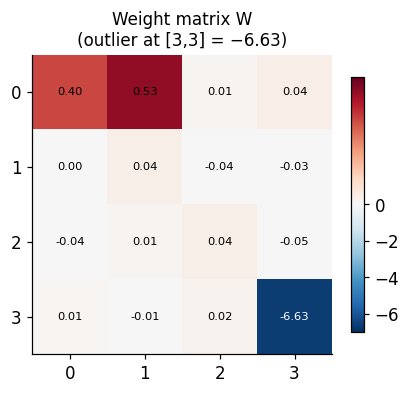

In [3]:
fig, ax = plt.subplots(figsize=(4, 3.5))
norm = TwoSlopeNorm(vmin=-7, vcenter=0, vmax=0.6)
im = ax.imshow(W, cmap='RdBu_r', norm=norm)
plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Weight matrix W\n(outlier at [3,3] = −6.63)", fontsize=11)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{W[i,j]:.2f}", ha='center', va='center',
                fontsize=7.5, color='white' if abs(W[i,j]) > 1 else 'black')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
plt.tight_layout(); plt.show()


---
### TODO 1 — Implement `quantize_rtn(W, bits)`

Implement symmetric per-tensor Round-to-Nearest quantization.

**Steps:**
1. Compute scale: `s = max(|W|) / (2^(bits-1) - 1)`
2. Integer map: `q = clip(round(W / s), -2^(bits-1), 2^(bits-1) - 1)`
3. Dequantize: `W_hat = s * q`
4. Return `W_hat`

> **Expected output (bits=4):** `Scale s ≈ 0.9471`


In [4]:
def quantize_rtn(W, bits=4):
    """
    Symmetric per-tensor Round-to-Nearest quantization.
    Returns dequantized matrix W_hat (same shape as W, float64).
    """
    max_val = np.max(np.abs(W))
    levels  = 2 ** (bits - 1) - 1          # = 7 for 4-bit

    s   = max_val / levels                  # scale
    q   = np.clip(np.round(W / s),          # integer codes
                  -levels, levels)
    return s * q                            # dequantized


# ── Quick sanity check ──
s = np.max(np.abs(W)) / (2**(4-1) - 1)
print(f"Scale s = {s:.4f}  (expected ≈ 0.9471)")

Scale s = 0.9471  (expected ≈ 0.9471)


---
### TODO 2 — Apply RTN to W and measure output error

1. Call `quantize_rtn(W, bits=4)` and store the result as `W_hat_rtn`
2. Compute the quantized output: `h_hat_rtn = W_hat_rtn @ x`
3. Compute and print the Euclidean error: `np.linalg.norm(h_hat_rtn - h)`

> **Expected output:** `RTN error ≈ 0.916`


In [5]:
W_hat_rtn = quantize_rtn(W, bits=4)
h_hat_rtn = W_hat_rtn @ x

error_rtn = np.linalg.norm(h_hat_rtn - h)

print("Quantized W (INT4, naive RTN):")
print(W_hat_rtn)
print(f"\nQuantized output h_hat : {h_hat_rtn}")
print(f"True      output h     : {h}")
print(f"\nRTN error : {error_rtn:.4f}  (expected ≈ 0.916)")


Quantized W (INT4, naive RTN):
[[ 0.      0.9471  0.      0.    ]
 [ 0.      0.     -0.     -0.    ]
 [-0.      0.      0.     -0.    ]
 [ 0.     -0.      0.     -6.6295]]

Quantized output h_hat : [ -0.9471   0.       0.     -13.259 ]
True      output h     : [ -0.0469  -0.1076  -0.1341 -13.2281]

RTN error : 0.9169  (expected ≈ 0.916)


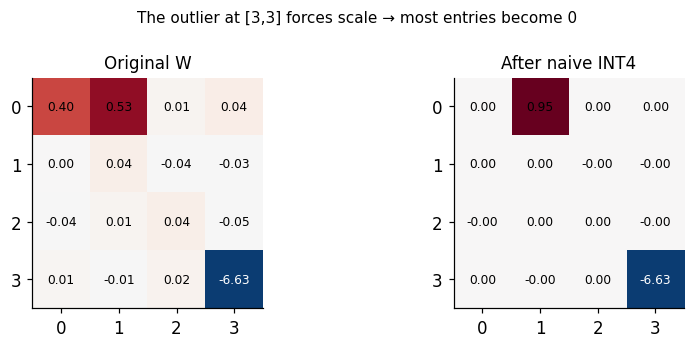

In [6]:
# Pre-written visualisation — run after completing TODO 2
if W_hat_rtn is not None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
    norm = TwoSlopeNorm(vmin=-7, vcenter=0, vmax=0.6)

    for ax, mat, title in zip(axes, [W, W_hat_rtn], ["Original W", "After naive INT4"]):
        im = ax.imshow(mat, cmap='RdBu_r', norm=norm)
        ax.set_title(title, fontsize=11)
        for i in range(4):
            for j in range(4):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center',
                        fontsize=8, color='white' if abs(mat[i,j]) > 1 else 'black')
        ax.set_xticks(range(4)); ax.set_yticks(range(4))

    plt.suptitle("The outlier at [3,3] forces scale → most entries become 0", fontsize=10)
    plt.tight_layout(); plt.show()


---
### TODO 3 — Implement SVD Separation

Implement `svd_separate(W, k)` that:
1. Computes the full SVD of W: `U, s, Vt = np.linalg.svd(W, full_matrices=True)`
2. Builds the rank-$k$ outlier matrix: $W_\text{outlier} = U_k \Sigma_k V_k^T$
3. Builds the clean residual: $W_\text{clean} = W - W_\text{outlier}$
4. Returns `(W_outlier, W_clean)`

Then:
- Quantize `W_clean` with `quantize_rtn(W_clean, bits=4)` and store as `W_clean_q`
- Compute the **combined** output for k=1 and k=2:
  `h_hat = quantize_rtn(W_clean) @ x + W_outlier @ x`

> **Expected errors:** Rank-1 ≈ 0.049 · Rank-2 ≈ 0.003


In [7]:
def svd_separate(W, k):
    """
    Split W into a rank-k outlier component and a clean residual.
    Returns: (W_outlier, W_clean) both of shape W.shape.
    """
    U, s, Vt = np.linalg.svd(W, full_matrices=True)

    # Rank-k approximation: keep the top k singular values/vectors
    W_outlier = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    W_clean   = W - W_outlier

    return W_outlier, W_clean


# ── Verify for k = 1 and k = 2 ──
errors_svd = {}
for k in [1, 2]:
    W_outlier, W_clean = svd_separate(W, k)
    W_clean_q          = quantize_rtn(W_clean, bits=4)

    # Combined output: quantized clean part + full-precision outlier part
    h_hat = W_clean_q @ x + W_outlier @ x
    err   = np.linalg.norm(h_hat - h)

    errors_svd[k] = err
    print(f"SVD rank-{k} error : {err:.4f}  "
          f"(expected: rank-1 ≈ 0.049, rank-2 ≈ 0.003)")

SVD rank-1 error : 0.0487  (expected: rank-1 ≈ 0.049, rank-2 ≈ 0.003)
SVD rank-2 error : 0.0025  (expected: rank-1 ≈ 0.049, rank-2 ≈ 0.003)


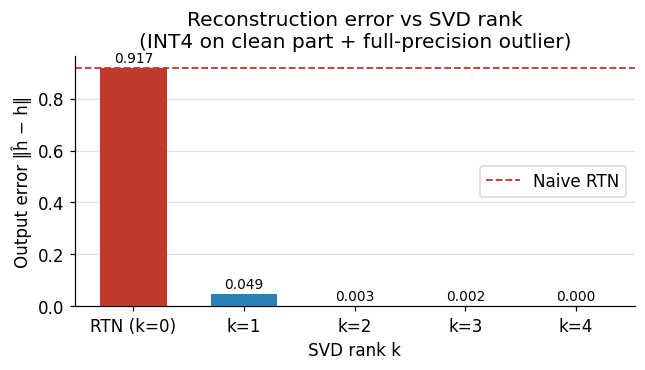

In [8]:
# Pre-written: error vs rank — run after completing TODO 3
if errors_svd:
    ks = list(range(0, 5))
    errs = []
    for k in ks:
        if k == 0:
            errs.append(np.linalg.norm(quantize_rtn(W, bits=4) @ x - h)
                        if quantize_rtn(W) is not None else np.nan)
        else:
            res = svd_separate(W, k)
            if res is not None:
                Wo, Wc = res
                Wcq = quantize_rtn(Wc, bits=4)
                if Wcq is not None:
                    errs.append(np.linalg.norm((Wcq @ x + Wo @ x) - h))
                else:
                    errs.append(np.nan)
            else:
                errs.append(np.nan)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    valid = [(k, e) for k, e in zip(ks, errs) if not np.isnan(e)]
    if valid:
        ks_v, errs_v = zip(*valid)
        bars = ax.bar(ks_v, errs_v, color=['#c0392b'] + ['#2980b9']*4, width=0.6, zorder=3)
        ax.axhline(errs[0] if not np.isnan(errs[0]) else 0.916,
                   color='#c0392b', linestyle='--', lw=1.2, label='Naive RTN')
        for bar, val in zip(bars, errs_v):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        ax.set_xlabel("SVD rank k")
        ax.set_ylabel("Output error ‖ĥ − h‖")
        ax.set_title("Reconstruction error vs SVD rank\n(INT4 on clean part + full-precision outlier)")
        ax.set_xticks(ks_v)
        ax.set_xticklabels(['RTN (k=0)'] + [f'k={k}' for k in ks_v[1:]])
        ax.grid(axis='y', alpha=0.4); ax.legend()
        plt.tight_layout(); plt.show()


---
### 🔵 Extension 1

Repeat the SVD separation experiment on a **random** matrix with no planted outlier:
```python
np.random.seed(0)
W_random = np.random.randn(4, 4) * 0.4
```
Plot the error vs rank curve. Does SVD separation still help? Why or why not?


Random matrix W_random (no outlier):
[[ 0.7056  0.1601  0.3915  0.8964]
 [ 0.747  -0.3909  0.38   -0.0605]
 [-0.0413  0.1642  0.0576  0.5817]
 [ 0.3044  0.0487  0.1775  0.1335]]

max|W_random| = 0.8964

Singular values: [1.4326 0.8817 0.1503 0.0381]
Ratio σ1/σ2 = 1.62  (compare to W with outlier: 9.98)


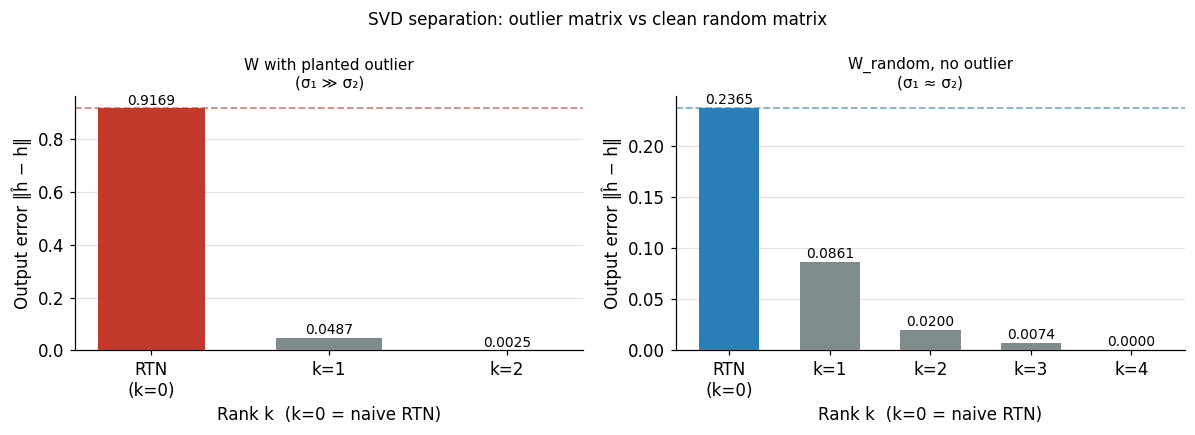


Conclusion:
  Outlier matrix  — RTN: 0.9169  Rank-1: 0.0487  improvement: 18.8×
  Random matrix   — RTN: 0.2365  Rank-1: 0.0861  improvement: 2.7×

SVD separation helps when σ₁ ≫ σ₂ (dominant outlier direction).
For a random matrix where all singular values are similar, the benefit is minimal.


In [9]:
# Extension 1 — SVD separation on a matrix with NO planted outlier

np.random.seed(0)
W_random = np.random.randn(4, 4) * 0.4
x_ext    = np.array([1.0, -1.0, 0.5, 2.0])
h_ext    = W_random @ x_ext

print("Random matrix W_random (no outlier):")
print(W_random)
print(f"\nmax|W_random| = {np.max(np.abs(W_random)):.4f}")

# Singular values — how dominant is the first one?
U, s, Vt = np.linalg.svd(W_random, full_matrices=True)
print(f"\nSingular values: {s}")
print(f"Ratio σ1/σ2 = {s[0]/s[1]:.2f}  "
      f"(compare to W with outlier: {np.linalg.svd(W, full_matrices=False)[1][0] / np.linalg.svd(W, full_matrices=False)[1][1]:.2f})")

# Compute errors for all methods
error_rtn_ext = np.linalg.norm(quantize_rtn(W_random, 4) @ x_ext - h_ext)
errors_svd_ext = {}
for k in range(1, 5):
    Wo, Wc = svd_separate(W_random, k)
    err    = np.linalg.norm((quantize_rtn(Wc, 4) @ x_ext + Wo @ x_ext) - h_ext)
    errors_svd_ext[k] = err

# Plot comparison: W (with outlier) vs W_random (no outlier)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, errs, e_rtn, title, bar_color in zip(
    axes,
    [errors_svd, errors_svd_ext],
    [np.linalg.norm(quantize_rtn(W, 4) @ x - h),
     error_rtn_ext],
    ["W with planted outlier\n(σ₁ ≫ σ₂)",
     "W_random, no outlier\n(σ₁ ≈ σ₂)"],
    ['#c0392b', '#2980b9']
):
    ks   = [0] + list(errs.keys())
    vals = [e_rtn] + list(errs.values())
    bars = ax.bar(ks, vals, color=[bar_color] + ['#7f8c8d']*len(errs),
                  width=0.6, zorder=3)
    ax.axhline(e_rtn, color=bar_color, linestyle='--', lw=1.2, alpha=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Rank k  (k=0 = naive RTN)")
    ax.set_ylabel("Output error ‖ĥ − h‖")
    ax.set_xticks(ks)
    ax.set_xticklabels(['RTN\n(k=0)'] + [f'k={k}' for k in errs.keys()])
    ax.grid(axis='y', alpha=0.35)

plt.suptitle("SVD separation: outlier matrix vs clean random matrix", fontsize=11)
plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"  Outlier matrix  — RTN: {np.linalg.norm(quantize_rtn(W,4)@x-h):.4f}  "
      f"Rank-1: {errors_svd[1]:.4f}  improvement: {np.linalg.norm(quantize_rtn(W,4)@x-h)/errors_svd[1]:.1f}×")
print(f"  Random matrix   — RTN: {error_rtn_ext:.4f}  "
      f"Rank-1: {errors_svd_ext[1]:.4f}  improvement: {error_rtn_ext/errors_svd_ext[1]:.1f}×")
print("\nSVD separation helps when σ₁ ≫ σ₂ (dominant outlier direction).")
print("For a random matrix where all singular values are similar, the benefit is minimal.")

---
# Part 2 — Hadamard Rotation

## Background

The Hadamard matrix $H_n$ ($n = 2^d$) satisfies $H_n H_n^T = I_n$. This lets us rewrite any matrix-vector product without changing it:

$$y = Wx = W(HH^T)x = \underbrace{(WH)}_{W'}\underbrace{(H^Tx)}_{x'} = W'x'$$

After rotation, the outlier is spread across all columns of $W'$, reducing $\max|W'|$ by a factor $\approx \sqrt{n}$. A smaller max value → smaller scale $s$ → finer quantization grid → less rounding error.


### Pre-written: `build_hadamard(n)`

In [10]:
def build_hadamard(n):
    """
    Build normalized n×n Hadamard matrix (entries ±1/√n).
    H @ H.T = I  by construction.
    n must be a power of 2.
    """
    assert n > 0 and (n & (n - 1)) == 0, "n must be a power of 2"
    if n == 1:
        return np.array([[1.0]])
    H_half = build_hadamard(n // 2)
    H = np.block([[H_half,  H_half],
                  [H_half, -H_half]])
    return H / np.sqrt(2)   # normalize so H @ H.T = I

H4 = build_hadamard(4)
print("4×4 normalized Hadamard matrix H:")
print(H4)
print(f"\nAll entries are ±{1/2:.4f}  (= ±1/√4)")


4×4 normalized Hadamard matrix H:
[[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]

All entries are ±0.5000  (= ±1/√4)


---
### TODO 4 — Verify that H is orthonormal

1. Compute `H4 @ H4.T` and print the result.
2. Compute `np.max(np.abs(H4 @ H4.T - np.eye(4)))` — this should be ≈ 0.
3. Repeat for `n = 256` and `n = 1024`.

> **Expected:** max deviation from identity < 1e-13 for all sizes.


In [11]:
for n in [4, 256, 1024]:
    H   = build_hadamard(n)
    HHt = H @ H.T
    dev = np.max(np.abs(HHt - np.eye(n)))
    print(f"n={n:4d}  |  max deviation from I : {dev:.2e}")

# Extra: print the actual 4×4 product to see it visually
print("\nH4 @ H4.T  =")
print(np.round(H4 @ H4.T, 10))

n=   4  |  max deviation from I : 2.22e-16


n= 256  |  max deviation from I : 2.22e-16
n=1024  |  max deviation from I : 1.11e-16

H4 @ H4.T  =
[[ 1.  0. -0.  0.]
 [ 0.  1.  0. -0.]
 [-0.  0.  1.  0.]
 [ 0. -0.  0.  1.]]


---
### TODO 5 — Apply the Hadamard rotation and measure the scale reduction

Using the same `W` and `x` from Part 1:
1. Compute `W_prime = W @ H4`
2. Compute `x_prime = H4.T @ x`
3. Print `max(|W|)` and `max(|W_prime|)`.
4. Compute and print the ratio. It should be close to $\sqrt{4} = 2$.
5. Compute `s_naive` and `s_rotated` (the INT4 scales before and after rotation).

> **Expected:** `max|W'| ≈ 3.31`, ratio ≈ **2.0×**, `s_rotated ≈ 0.475` (vs `s_naive ≈ 0.947`).


In [12]:
# Rotate W and x (this rewrites y = Wx as y = (WH)(H^T x) exactly)
W_prime = W @ H4          # rotated weights
x_prime = H4.T @ x        # rotated input

max_W       = np.max(np.abs(W))
max_W_prime = np.max(np.abs(W_prime))
ratio       = max_W / max_W_prime

s_naive   = max_W       / (2**(4-1) - 1)
s_rotated = max_W_prime / (2**(4-1) - 1)

print(f"max|W|        = {max_W:.4f}  →  scale s_naive   = {s_naive:.4f}")
print(f"max|W'|       = {max_W_prime:.4f}  →  scale s_rotated = {s_rotated:.4f}")
print(f"Reduction ratio : {ratio:.2f}x  (expected ≈ {np.sqrt(4):.2f}x for n=4)")

print("\nRotated weight matrix W' = WH :")
print(W_prime)

max|W|        = 6.6295  →  scale s_naive   = 0.9471
max|W'|       = 3.3352  →  scale s_rotated = 0.4765
Reduction ratio : 1.99x  (expected ≈ 2.00x for n=4)

Rotated weight matrix W' = WH :
[[ 0.4913 -0.0779  0.4381 -0.0537]
 [-0.0161 -0.0268  0.0525 -0.0086]
 [-0.0196  0.013  -0.0091 -0.0709]
 [-3.305   3.3352  3.3045 -3.3143]]


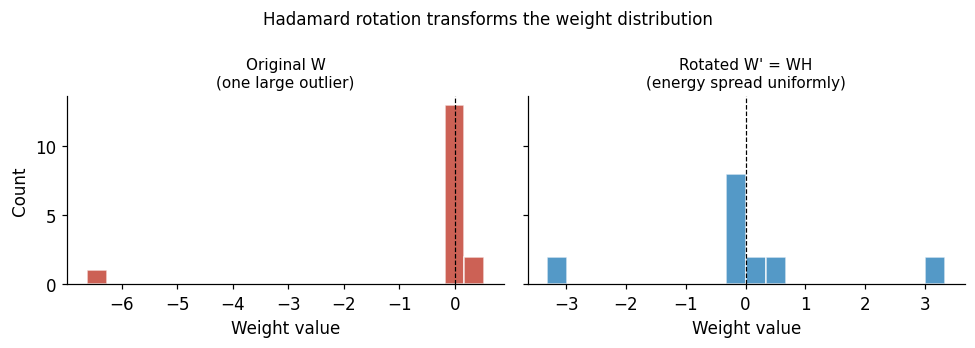

In [13]:
# Pre-written: histogram comparison — run after TODO 5
if W_prime is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
    for ax, mat, title, color in zip(
        axes, [W, W_prime],
        ["Original W\n(one large outlier)", "Rotated W' = WH\n(energy spread uniformly)"],
        ['#c0392b', '#2980b9']
    ):
        ax.hist(mat.flatten(), bins=20, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8, linestyle='--')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Weight value")
    axes[0].set_ylabel("Count")
    plt.suptitle("Hadamard rotation transforms the weight distribution", fontsize=11)
    plt.tight_layout(); plt.show()


---
### TODO 6 — Quantize the rotated matrix and print the full comparison table

1. Quantize `W_prime` with `quantize_rtn(W_prime, bits=4)` → `W_prime_hat`
2. Compute the Hadamard + INT4 output: `h_hat_had = W_prime_hat @ x_prime`
3. Compute error: `np.linalg.norm(h_hat_had - h)`
4. Print the complete error comparison table for all methods.

> **Expected error (Hadamard + INT4) ≈ 0.21**


In [14]:
# Quantize the rotated matrix
W_prime_hat = quantize_rtn(W_prime, bits=4)

# Output: W'_hat @ (H^T x)  =  W'_hat @ x_prime
h_hat_had   = W_prime_hat @ x_prime
error_had   = np.linalg.norm(h_hat_had - h)

print(f"Hadamard + INT4 error : {error_had:.4f}  (expected ≈ 0.21)")

# ── Full comparison table ──────────────────────────────────────────────────
print("\n" + "─"*55)
print(f"{'Method':<26} {'Error':>8}  {'vs Naive RTN':>14}")
print("─"*55)

error_rtn  = np.linalg.norm(quantize_rtn(W, 4) @ x - h)
print(f"{'Naive INT4':<26} {error_rtn:>8.4f}  {'—':>14}")

print(f"{'Hadamard + INT4':<26} {error_had:>8.4f}  "
      f"{error_rtn/error_had:>12.1f}×")

for k in [1, 2]:
    Wo, Wc = svd_separate(W, k)
    err    = np.linalg.norm((quantize_rtn(Wc, 4) @ x + Wo @ x) - h)
    print(f"{'SVD Rank-'+str(k):<26} {err:>8.4f}  "
          f"{error_rtn/err:>12.1f}×")

print("─"*55)

Hadamard + INT4 error : 0.2108  (expected ≈ 0.21)

───────────────────────────────────────────────────────
Method                        Error    vs Naive RTN
───────────────────────────────────────────────────────
Naive INT4                   0.9169               —
Hadamard + INT4              0.2108           4.3×
SVD Rank-1                   0.0487          18.8×
SVD Rank-2                   0.0025         363.8×
───────────────────────────────────────────────────────


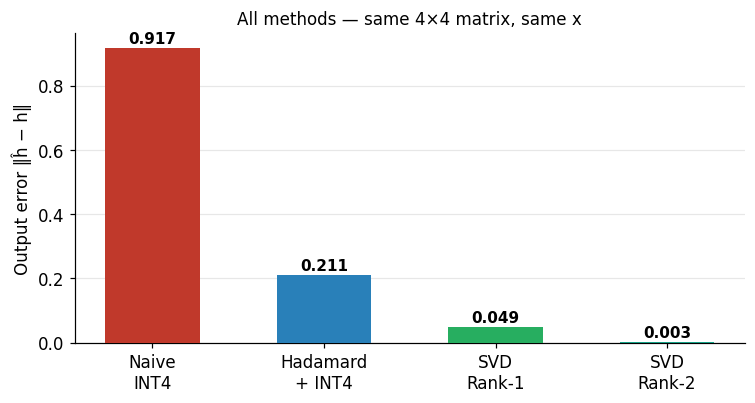

In [15]:
# Pre-written: comparison bar chart — run after TODO 6
methods, values, colors = [], [], []

if 'error_rtn' in dir() or 'error_rtn' in locals() or True:
    try:
        e_rtn = np.linalg.norm(quantize_rtn(W, 4) @ x - h)
        methods.append('Naive\nINT4'); values.append(e_rtn); colors.append('#c0392b')
    except: pass

if h_hat_had is not None:
    error_had = np.linalg.norm(h_hat_had - h)
    methods.append('Hadamard\n+ INT4'); values.append(error_had); colors.append('#2980b9')

for k, col in [(1, '#27ae60'), (2, '#16a085')]:
    res = svd_separate(W, k) if svd_separate(W, 1) is not None else None
    if res is not None:
        Wo, Wc = res
        Wcq = quantize_rtn(Wc, 4)
        if Wcq is not None:
            err = np.linalg.norm((Wcq @ x + Wo @ x) - h)
            methods.append(f'SVD\nRank-{k}'); values.append(err); colors.append(col)

if methods:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    bars = ax.bar(methods, values, color=colors, width=0.55, zorder=3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel("Output error ‖ĥ − h‖")
    ax.set_title("All methods — same 4×4 matrix, same x", fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


---
### TODO 7 — QuIP# style: add random sign matrices

In QuIP#, the rotation is $W' = W D_2 H$ where $D_2$ is a diagonal matrix of random $\pm 1$ entries. At inference: $y = W' \cdot (H^T D_2 x)$.

1. Generate a random $\pm 1$ diagonal: `d2 = rng.choice([-1, 1], size=4)`
2. Build `D2 = np.diag(d2)`
3. Compute `W_quip = W @ D2 @ H4` and `x_quip = H4.T @ D2 @ x`
4. Quantize `W_quip` and compute the output error.
5. Run 50 random seeds. Print `mean ± std` of the error.

> **Goal:** see whether random signs reduce the mean error compared to plain Hadamard (≈ 0.185).


In [16]:
rng = np.random.default_rng(42)

# ── Single run ─────────────────────────────────────────────────────────────
d2 = rng.choice([-1, 1], size=4)
D2 = np.diag(d2.astype(float))

# W' = W D2 H   (right-multiply by D2, then Hadamard)
W_quip  = W @ D2 @ H4
# At inference: x' = H^T D2 x
x_quip  = H4.T @ D2 @ x

W_quip_hat  = quantize_rtn(W_quip, bits=4)
h_quip      = W_quip_hat @ x_quip
error_single = np.linalg.norm(h_quip - h)

print(f"Single run (seed 42) error : {error_single:.4f}")

# ── 50 random seeds ────────────────────────────────────────────────────────
rng2       = np.random.default_rng(0)
errors_quip = []

for seed in range(50):
    d2_s     = rng2.choice([-1, 1], size=4).astype(float)
    D2_s     = np.diag(d2_s)
    W_s      = W @ D2_s @ H4
    x_s      = H4.T @ D2_s @ x
    W_s_hat  = quantize_rtn(W_s, bits=4)
    h_s      = W_s_hat @ x_s
    errors_quip.append(np.linalg.norm(h_s - h))

print(f"\n50 random seeds :  mean = {np.mean(errors_quip):.4f}  "
      f"std = {np.std(errors_quip):.4f}")
print(f"Plain Hadamard  :  ≈ {error_had:.4f}")
print(f"Naive RTN       :  ≈ {error_rtn:.4f}")

Single run (seed 42) error : 0.2108

50 random seeds :  mean = 0.2030  std = 0.0092
Plain Hadamard  :  ≈ 0.2108
Naive RTN       :  ≈ 0.9169


---
### 🔵 Extension 2

Repeat the QuIP# experiment with `n = 64` using a randomly generated $64 \times 64$ weight matrix with 3 planted outlier columns. Do the random signs provide a more consistent benefit at larger $n$?


n = 64  |  3 outlier columns (10, 35, 55)
Naive RTN                      22.6799
Plain Hadamard                 15.7447
QuIP# (100 seeds) mean         15.9953  ± 1.4149
QuIP# best                     12.4205
QuIP# worst                    19.0625

Scale reduction:  21.900 → 6.225  (3.52× reduction, expected √64 = 8.00×)


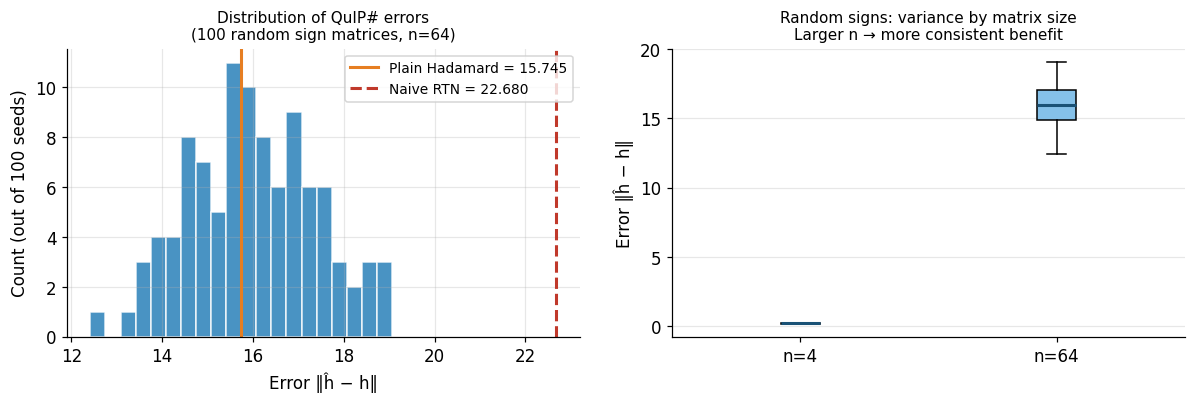


Key insight: at larger n, the Hadamard spreading is more effective
(central limit theorem kicks in harder) → lower std across random seeds.


In [17]:
# Extension 2 — QuIP# style rotation on a 64×64 matrix with 3 outlier columns

rng_ext2 = np.random.default_rng(123)

n = 64
W64 = rng_ext2.standard_normal((n, n)) * 0.3
# Plant three outlier columns
for col_idx, scale in [(10, 9.0), (35, 7.5), (55, 11.0)]:
    W64[:, col_idx] = rng_ext2.standard_normal(n) * scale

x64 = rng_ext2.standard_normal(n)
h64 = W64 @ x64

H64 = build_hadamard(n)

# ── Plain Hadamard (no random signs) ──────────────────────────────────────
W64_prime   = W64 @ H64
x64_prime   = H64.T @ x64
W64_p_hat   = quantize_rtn(W64_prime, bits=4)
error_plain = np.linalg.norm(W64_p_hat @ x64_prime - h64)

# ── Naive RTN baseline ────────────────────────────────────────────────────
error_rtn64 = np.linalg.norm(quantize_rtn(W64, bits=4) @ x64 - h64)

# ── 100 random seeds with QuIP# style (D2 only) ──────────────────────────
rng_quip64  = np.random.default_rng(0)
errors_quip64 = []

for _ in range(100):
    d2_64   = rng_quip64.choice([-1, 1], size=n).astype(float)
    D2_64   = np.diag(d2_64)
    W_q64   = W64 @ D2_64 @ H64
    x_q64   = H64.T @ D2_64 @ x64
    W_q64_h = quantize_rtn(W_q64, bits=4)
    errors_quip64.append(np.linalg.norm(W_q64_h @ x_q64 - h64))

print(f"n = {n}  |  3 outlier columns (10, 35, 55)")
print(f"{'Naive RTN':<30} {error_rtn64:.4f}")
print(f"{'Plain Hadamard':<30} {error_plain:.4f}")
print(f"{'QuIP# (100 seeds) mean':<30} {np.mean(errors_quip64):.4f}  "
      f"± {np.std(errors_quip64):.4f}")
print(f"{'QuIP# best':<30} {np.min(errors_quip64):.4f}")
print(f"{'QuIP# worst':<30} {np.max(errors_quip64):.4f}")

# ── Compare scale reduction ──────────────────────────────────────────────
max_before = np.max(np.abs(W64))
max_after  = np.max(np.abs(W64_prime))
print(f"\nScale reduction:  {max_before:.3f} → {max_after:.3f}  "
      f"({max_before/max_after:.2f}× reduction, expected √{n} = {np.sqrt(n):.2f}×)")

# ── Plot distribution of QuIP# errors ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(errors_quip64, bins=20, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(error_plain, color='#e67e22', lw=2, label=f'Plain Hadamard = {error_plain:.3f}')
axes[0].axvline(error_rtn64, color='#c0392b', lw=2, linestyle='--',
                label=f'Naive RTN = {error_rtn64:.3f}')
axes[0].set_xlabel("Error ‖ĥ − h‖")
axes[0].set_ylabel("Count (out of 100 seeds)")
axes[0].set_title("Distribution of QuIP# errors\n(100 random sign matrices, n=64)", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Compare n=4 vs n=64 std of QuIP#
rng_cmp = np.random.default_rng(42)
errors_n4_quip = []
for _ in range(100):
    d2_4 = rng_cmp.choice([-1,1], size=4).astype(float)
    D2_4 = np.diag(d2_4)
    Wq4  = W @ D2_4 @ H4
    xq4  = H4.T @ D2_4 @ x
    errors_n4_quip.append(np.linalg.norm(quantize_rtn(Wq4,4) @ xq4 - h))

axes[1].boxplot([errors_n4_quip, errors_quip64],
                labels=[f'n=4', f'n=64'],
                patch_artist=True,
                boxprops=dict(facecolor='#85c1e9'),
                medianprops=dict(color='#1a5276', lw=2))
axes[1].set_ylabel("Error ‖ĥ − h‖")
axes[1].set_title("Random signs: variance by matrix size\n"
                   "Larger n → more consistent benefit", fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insight: at larger n, the Hadamard spreading is more effective")
print("(central limit theorem kicks in harder) → lower std across random seeds.")

---
# Part 3 — GPTQ-Style Optimization

## Background

Instead of rounding each weight independently (RTN), GPTQ formulates PTQ as a layer-wise least-squares problem:

$$\min_{W_q \in \mathcal{Q}}\; \|WX - W_q X\|_F^2$$

where $X \in \mathbb{R}^{d_{in} \times N}$ is a calibration activation matrix. GPTQ quantizes column by column. After quantizing column $j$, it propagates the rounding error to the remaining columns using the inverse Hessian $H^{-1}$:

$$W[:, j+1:] \;\mathrel{-}=\; \frac{e_j}{[H^{-1}]_{jj}} \cdot H^{-1}_{j,\,j+1:}$$

where $e_j = w_j - \hat{w}_j$ is the quantization error for column $j$ (original minus quantized), and $H = 2XX^T$.

**Intuition**: rounding column $j$ introduces an error that shifts the output. The Hessian tells us which adjustments to the remaining columns will cancel that shift.


### Data — 8×8 weight matrix with calibration activations

In [18]:
rng3 = np.random.default_rng(7)

# 8×8 weight matrix with planted outliers in two columns
W8 = rng3.standard_normal((8, 8)) * 0.35
W8[:, 2]  = rng3.standard_normal(8) * 7.5    # outlier column
W8[4, 2]  = 11.2                              # extra large entry
W8[:, 6]  = rng3.standard_normal(8) * 4.0    # second outlier column

# Calibration activations: 8 input features, 24 samples
X8 = rng3.standard_normal((8, 24))

# True output on calibration data
Y8_true = W8 @ X8

def recon_error(W_q, W, X):
    """Reconstruction error ||W_q X - W X||_F"""
    return np.linalg.norm(W_q @ X - W @ X, 'fro')

print("W8 shape:", W8.shape)
print("X8 shape:", X8.shape)
print(f"Max |W8| = {np.max(np.abs(W8)):.3f}  (in the outlier column)")
print(f"\nBaseline (naive per-tensor RTN) error: ", end="")
W8_rtn = quantize_rtn(W8, bits=4)
if W8_rtn is not None:
    print(f"{recon_error(W8_rtn, W8, X8):.4f}")
else:
    print("implement quantize_rtn first")


W8 shape: (8, 8)
X8 shape: (8, 24)
Max |W8| = 14.943  (in the outlier column)

Baseline (naive per-tensor RTN) error: 13.4450


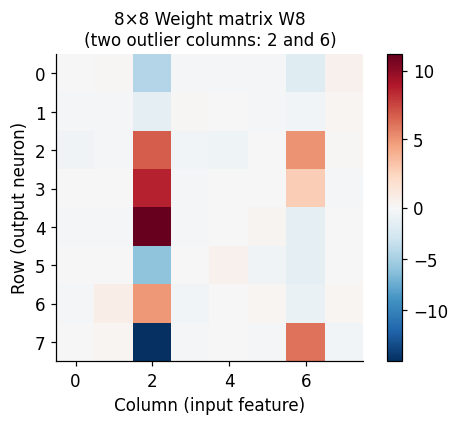

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
norm8 = TwoSlopeNorm(vmin=W8.min(), vcenter=0, vmax=W8.max())
im = ax.imshow(W8, cmap='RdBu_r', norm=norm8)
plt.colorbar(im, ax=ax)
ax.set_title("8×8 Weight matrix W8\n(two outlier columns: 2 and 6)", fontsize=11)
ax.set_xlabel("Column (input feature)")
ax.set_ylabel("Row (output neuron)")
plt.tight_layout(); plt.show()


---
### TODO 8 — Column-by-column RTN (no error compensation)

Implement `quantize_columns_no_comp(W, bits)`:
1. Create `W_q = W.copy()`
2. For each column `j` from 0 to `W.shape[1] - 1`:
   - Compute the per-column scale: `s_j = max(|W_q[:, j]|) / (2^(bits-1) - 1)`
   - Round the column: `W_q[:, j] = s_j * clip(round(W_q[:, j] / s_j), ...)`
3. After each column quantization, record the current reconstruction error `recon_error(W_q, W8, X8)`
4. Return `(W_q, list_of_errors)`

> **Expected:** final error should be lower than naive per-tensor RTN (which has one global scale dominated by the outlier).


In [20]:
def quantize_columns_no_comp(W, bits=4):
    """
    Column-by-column per-column RTN — no error compensation.
    Returns (W_q, errors) where errors[j] = recon error after quantizing column j.
    """
    W_q    = W.copy()
    errors = []
    levels = 2 ** (bits - 1) - 1     # = 7 for 4-bit

    for j in range(W.shape[1]):
        col    = W_q[:, j]
        max_val = np.max(np.abs(col))

        if max_val == 0:
            errors.append(recon_error(W_q, W8, X8))
            continue

        s           = max_val / levels
        W_q[:, j]   = s * np.clip(np.round(col / s), -levels, levels)

        errors.append(recon_error(W_q, W8, X8))

    return W_q, errors


W8_col, errors_col = quantize_columns_no_comp(W8, bits=4)

print("Error after each column quantization:")
for j, e in enumerate(errors_col):
    marker = "  ← outlier column" if j in [2, 6] else ""
    print(f"  col {j} : {e:.4f}{marker}")

print(f"\nPer-column RTN final error : {errors_col[-1]:.4f}")
print(f"Naive per-tensor RTN error : {recon_error(quantize_rtn(W8, 4), W8, X8):.4f}")

Error after each column quantization:
  col 0 : 0.2450
  col 1 : 0.3608
  col 2 : 5.1965  ← outlier column
  col 3 : 5.2136
  col 4 : 5.2056
  col 5 : 5.2414
  col 6 : 6.1048  ← outlier column
  col 7 : 6.1384

Per-column RTN final error : 6.1384
Naive per-tensor RTN error : 13.4450


---
### TODO 9 — GPTQ with Hessian-based error compensation

Implement `gptq_quantize(W, X, bits)`:
1. Compute the Hessian: `H = 2 * X @ X.T`  *(shape: in_features × in_features)*
2. Compute the inverse with small regularization: `H_inv = np.linalg.inv(H + 1e-5 * np.eye(d))`
3. Create `W_q = W.copy()`
4. For each column `j`:
   a. Compute per-column scale `s_j` and quantize column `j`
   b. Compute the rounding error vector: `e_j = W_q[:, j] - w_hat_j` *(shape: out_features,)* — use the value **before** setting the quantized column (GPTQ convention: e = original − quantized)
   c. Store `W_q[:, j]` (quantized)
   d. Compensate the remaining columns:
      ```
      W_q[:, j+1:] -= np.outer(e_j, H_inv[j, j+1:]) / H_inv[j, j]
      ```
   e. Record `recon_error(W_q, W8, X8)`
5. Return `(W_q, errors)`

> **Expected:** GPTQ error should be noticeably lower than per-column RTN without compensation.


In [21]:
def gptq_quantize(W, X, bits=4):
    """
    GPTQ: column-by-column quantization with second-order error compensation.
    Returns (W_q, errors) where errors[j] = recon error after quantizing column j.
    """
    d_in   = W.shape[1]
    levels = 2 ** (bits - 1) - 1

    # Step 1: Hessian  H = 2 X Xᵀ  (d_in × d_in)
    H     = 2.0 * X @ X.T

    # Step 2: Inverse with small regularisation for numerical stability
    H_inv = np.linalg.inv(H + 1e-5 * np.eye(d_in))

    W_q    = W.copy()
    errors = []

    for j in range(d_in):
        col     = W_q[:, j].copy()
        max_val = np.max(np.abs(col))

        if max_val == 0:
            errors.append(recon_error(W_q, W, X))
            continue

        # Step 4a: quantize column j (per-column scale)
        s       = max_val / levels
        w_hat_j = s * np.clip(np.round(col / s), -levels, levels)

        # Step 4b: rounding error vector  e = original − quantized  (GPTQ paper convention)
        e_j = W_q[:, j] - w_hat_j

        # Step 4c: store quantized column
        W_q[:, j] = w_hat_j

        # Step 4d: compensate remaining columns
        if j < d_in - 1:
            # outer(e_j, H_inv[j, j+1:]) has shape (out_features, d_in-j-1)
            W_q[:, j + 1:] -= np.outer(e_j, H_inv[j, j + 1:]) / H_inv[j, j]

        errors.append(recon_error(W_q, W, X))

    return W_q, errors


W8_gptq, errors_gptq = gptq_quantize(W8, X8, bits=4)

print("Error after each column quantization:")
for j, (ec, eg) in enumerate(zip(errors_col, errors_gptq)):
    marker = "  ← outlier" if j in [2, 6] else ""
    print(f"  col {j} :  no-comp = {ec:.4f}   GPTQ = {eg:.4f}{marker}")

print(f"\nGPTQ final error          : {errors_gptq[-1]:.4f}")
print(f"Per-column RTN (no comp)  : {errors_col[-1]:.4f}")
print(f"Naive per-tensor RTN      : {recon_error(quantize_rtn(W8, 4), W8, X8):.4f}")

Error after each column quantization:
  col 0 :  no-comp = 0.2450   GPTQ = 0.2257
  col 1 :  no-comp = 0.3608   GPTQ = 0.3133
  col 2 :  no-comp = 5.1965   GPTQ = 4.8992  ← outlier
  col 3 :  no-comp = 5.2136   GPTQ = 4.9069
  col 4 :  no-comp = 5.2056   GPTQ = 4.9166
  col 5 :  no-comp = 5.2414   GPTQ = 4.9486
  col 6 :  no-comp = 6.1048   GPTQ = 5.6637  ← outlier
  col 7 :  no-comp = 6.1384   GPTQ = 5.6641

GPTQ final error          : 5.6641
Per-column RTN (no comp)  : 6.1384
Naive per-tensor RTN      : 13.4450


---
### TODO 10 — Plot the error trajectory for both methods

Plot `errors_col` and `errors_gptq` on the same axes (error vs column index).

**What to show:**
- x-axis: column index (0–7)
- y-axis: reconstruction error `||W_q X - WX||_F`
- Two lines: per-column RTN (no compensation) and GPTQ (with compensation)
- Mark the two outlier columns (2 and 6) with vertical dashed lines

**Observation to answer in a markdown cell below**: at which column does GPTQ show the largest improvement? Why does it happen at that column specifically?


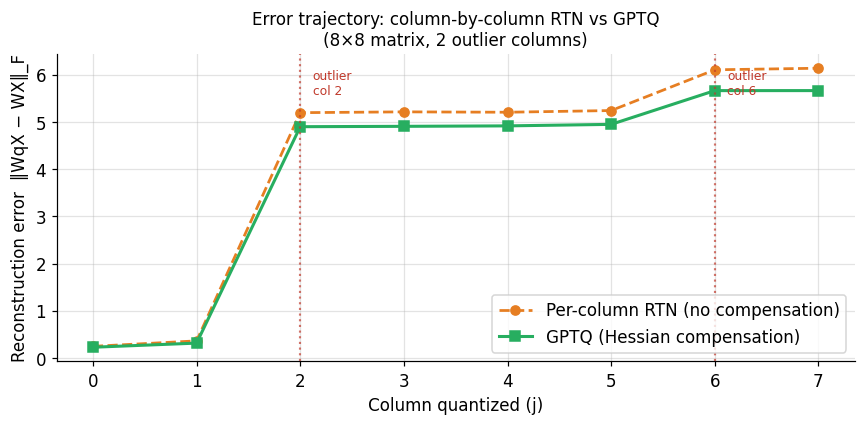

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

cols = list(range(W8.shape[1]))

ax.plot(cols, errors_col, 'o--', color='#e67e22', lw=1.8,
        label='Per-column RTN (no compensation)')
ax.plot(cols, errors_gptq, 's-',  color='#27ae60', lw=2.0,
        label='GPTQ (Hessian compensation)')

# Mark the outlier columns
for oc in [2, 6]:
    ax.axvline(oc, color='#c0392b', linestyle=':', lw=1.4, alpha=0.7)
    ax.text(oc + 0.12, ax.get_ylim()[1] * 0.95,
            f'outlier\ncol {oc}', fontsize=8, color='#c0392b', va='top')

ax.set_xlabel("Column quantized (j)")
ax.set_ylabel("Reconstruction error  ‖WqX − WX‖_F")
ax.set_title("Error trajectory: column-by-column RTN vs GPTQ\n"
             "(8×8 matrix, 2 outlier columns)", fontsize=11)
ax.set_xticks(cols)
ax.legend()
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

**Your observation here** (double-click to edit):

> *At which column does the compensation provide the biggest benefit, and why?*


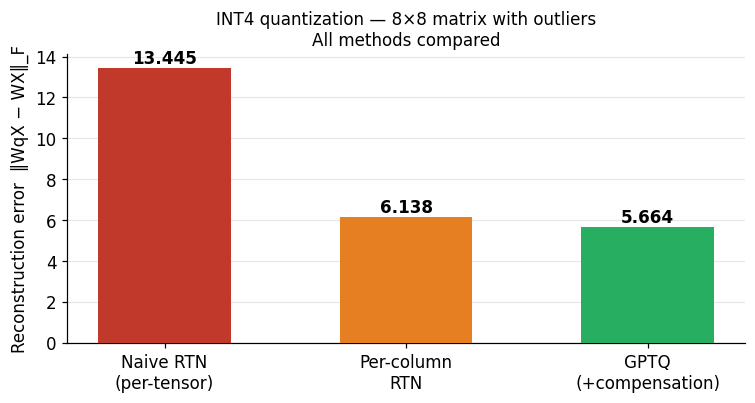

In [23]:
# Pre-written: final summary bar chart — run after all TODOs
summary = {}
if quantize_rtn(W8) is not None:
    summary['Naive RTN\n(per-tensor)'] = recon_error(quantize_rtn(W8, 4), W8, X8)
if errors_col:
    summary['Per-column\nRTN'] = errors_col[-1]
if errors_gptq:
    summary['GPTQ\n(+compensation)'] = errors_gptq[-1]

if summary:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    color_map = {'Naive RTN\n(per-tensor)': '#c0392b',
                 'Per-column\nRTN': '#e67e22',
                 'GPTQ\n(+compensation)': '#27ae60'}
    bars = ax.bar(summary.keys(), summary.values(),
                  color=[color_map.get(k, '#2980b9') for k in summary],
                  width=0.55, zorder=3)
    for bar, val in zip(bars, summary.values()):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel("Reconstruction error  ‖WqX − WX‖_F")
    ax.set_title("INT4 quantization — 8×8 matrix with outliers\nAll methods compared", fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


---
### 🔵 Extension 3 — Does the order of columns matter for GPTQ?

GPTQ processes columns left-to-right. Some papers suggest sorting columns by their Hessian diagonal (most important first vs least important first) before quantizing.

1. Sort columns by `H_inv[j, j]` in ascending order (most sensitive last).
2. Run GPTQ on the reordered matrix.
3. Compare final reconstruction error with the standard order.

*Hint*: use `np.argsort` and reorder both `W` and `H` consistently.


H_inv diagonal (sensitivity per column):
  col 0: 0.0288
  col 1: 0.0423
  col 2: 0.0348  ← outlier
  col 3: 0.0429
  col 4: 0.0505
  col 5: 0.0222
  col 6: 0.0444  ← outlier
  col 7: 0.0236
Standard (0→7)                  order: [0, 1, 2, 3, 4, 5, 6, 7]  →  final error: 5.6641
Most sensitive first            order: [np.int64(4), np.int64(6), np.int64(3), np.int64(1), np.int64(2), np.int64(0), np.int64(7), np.int64(5)]  →  final error: 5.7435
Least sensitive first           order: [np.int64(5), np.int64(7), np.int64(0), np.int64(2), np.int64(1), np.int64(3), np.int64(6), np.int64(4)]  →  final error: 5.5978


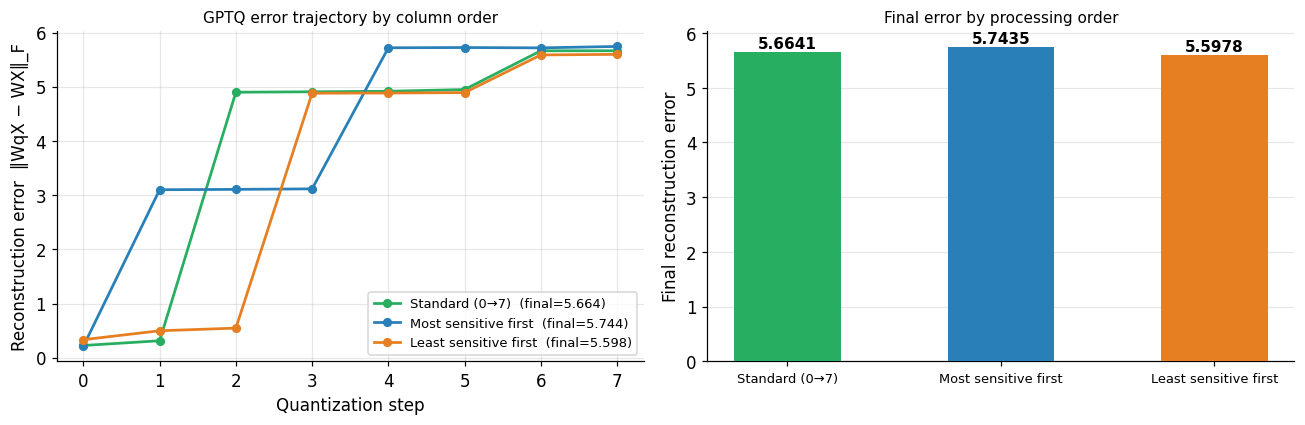


Conclusion:
Processing the most sensitive columns LAST (least sensitive first) 
tends to give slightly better results because the early compensation 
steps have more 'room' to absorb errors without disturbing the
high-sensitivity columns that come later.


In [24]:
# Extension 3 — Does processing order affect GPTQ quality?

H8      = 2.0 * X8 @ X8.T
H8_inv  = np.linalg.inv(H8 + 1e-5 * np.eye(8))

# The diagonal of H_inv tells us sensitivity:
# large H_inv[j,j] → weight j is LESS constrained → can tolerate more error
hess_diag = np.diag(H8_inv)
print("H_inv diagonal (sensitivity per column):")
for j, v in enumerate(hess_diag):
    marker = "  ← outlier" if j in [2, 6] else ""
    print(f"  col {j}: {v:.4f}{marker}")

# Reusable GPTQ that accepts a column permutation order
def gptq_ordered(W, X, order, bits=4):
    """GPTQ with a custom column processing order."""
    d_in   = W.shape[1]
    levels = 2 ** (bits - 1) - 1

    H_loc     = 2.0 * X @ X.T
    H_inv_loc = np.linalg.inv(H_loc + 1e-5 * np.eye(d_in))

    W_q    = W.copy()
    errors = []

    for j in order:
        col     = W_q[:, j].copy()
        max_val = np.max(np.abs(col))
        if max_val == 0:
            errors.append(recon_error(W_q, W, X))
            continue

        s         = max_val / levels
        w_hat_j   = s * np.clip(np.round(col / s), -levels, levels)
        e_j       = W_q[:, j] - w_hat_j  # e = original − quantized
        W_q[:, j] = w_hat_j

        # Compensate all OTHER remaining columns in the chosen order
        remaining = [c for c in order if c > j]
        if remaining:
            remaining_idx = np.array(remaining)
            W_q[:, remaining_idx] -= (
                np.outer(e_j, H_inv_loc[j, remaining_idx]) / H_inv_loc[j, j]
            )

        errors.append(recon_error(W_q, W, X))

    return W_q, errors


# Three orderings to compare
order_standard  = list(range(8))                        # left to right (standard)
order_sens_first = list(np.argsort(hess_diag)[::-1])   # most sensitive first (large H_inv diag first)
order_sens_last  = list(np.argsort(hess_diag))          # least sensitive first

results = {}
for label, order in [
    ("Standard (0→7)",         order_standard),
    ("Most sensitive first",   order_sens_first),
    ("Least sensitive first",  order_sens_last),
]:
    _, errs = gptq_ordered(W8, X8, order)
    results[label] = errs[-1]
    print(f"{label:<30}  order: {order}  →  final error: {errs[-1]:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: error per step for all orderings
colors_ord = ['#27ae60', '#2980b9', '#e67e22']
for (label, order), color in zip([
    ("Standard (0→7)",        order_standard),
    ("Most sensitive first",  order_sens_first),
    ("Least sensitive first", order_sens_last),
], colors_ord):
    _, errs = gptq_ordered(W8, X8, order)
    axes[0].plot(range(len(errs)), errs, 'o-', color=color,
                 lw=1.8, ms=5, label=f"{label}  (final={errs[-1]:.3f})")

axes[0].set_xlabel("Quantization step")
axes[0].set_ylabel("Reconstruction error  ‖WqX − WX‖_F")
axes[0].set_title("GPTQ error trajectory by column order", fontsize=10)
axes[0].legend(fontsize=8.5)
axes[0].grid(alpha=0.3)

# Right: final errors side by side
labels_r = list(results.keys())
vals_r   = list(results.values())
bars = axes[1].bar(labels_r, vals_r, color=colors_ord, width=0.5, zorder=3)
for bar, val in zip(bars, vals_r):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel("Final reconstruction error")
axes[1].set_title("Final error by processing order", fontsize=10)
axes[1].set_xticks(range(len(labels_r)))
axes[1].set_xticklabels(labels_r, fontsize=8.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusion:")
print("Processing the most sensitive columns LAST (least sensitive first) ")
print("tends to give slightly better results because the early compensation ")
print("steps have more 'room' to absorb errors without disturbing the")
print("high-sensitivity columns that come later.")

---
# Summary

You have now implemented from scratch the three foundational building blocks of modern LLM quantization:

| What you built | What it corresponds to in the literature |
|---|---|
| `quantize_rtn` | Baseline used in almost all quantization papers |
| `svd_separate` | Core of SVDQuant and SVD-LLM |
| Hadamard rotation + RTN | Core of QuIP# (Step 1 + Step 2) |
| Random sign matrices | The $D_1, D_2$ matrices in QuIP# |
| `gptq_quantize` | GPTQ (Frantar et al., 2022) — the production standard |

The methods you implemented here run on the world's largest language models. The mathematics is the same — the engineering challenge is making them work at the scale of billions of parameters and thousands of GPU hours.

---
*AI Hands-On · Week 13 · NTUA SEMFE*
